<a href="https://colab.research.google.com/github/diyapatel1225-cmyk/Tomato_Leaf_Disease_Detection-Severity_Assessment/blob/main/Tomato_Disease_Detection_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tomato Leaf Disease Detection + Severity Assessment — EfficientNetB0 Variant

**Project:** AI-Based Tomato Plant Disease Detection and Severity Assessment Using Deep Learning

This notebook is the **EfficientNetB0 counterpart** of your original MobileNetV2 notebook. Every step —
data loading, severity labeling, train/val/test split, augmentation, training schedule, evaluation, and
Grad-CAM — is kept **identical** to the MobileNetV2 version. The **only** thing that changes is the
backbone (feature extractor) and the handful of lines that depend on it (preprocessing function, and the
Grad-CAM last-conv-layer name).

This is intentional: for a fair backbone-comparison ablation in your paper, every other variable must be
held constant. Only change one thing at a time — the backbone — so any accuracy difference you see is
actually attributable to the architecture, not to a different data split or augmentation setup.

## Step 1: Setup & Imports

Same as before — no changes here.

In [ ]:
!pip install -q tensorflow opencv-python scikit-learn seaborn kaggle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os, shutil, random, zipfile, json, time
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Get the Dataset

Same dataset, same path — edit `ZIP_PATH` if needed, exactly as in your MobileNetV2 notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/Tomato_Project/tomato_leaves.zip"

EXTRACT_PATH = "/content/data"
os.makedirs(EXTRACT_PATH, exist_ok=True)

if not os.path.exists(os.path.join(EXTRACT_PATH, "tomato_leaves")):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extracted dataset to", EXTRACT_PATH)
else:
    print("Dataset already extracted, skipping unzip.")

DATA_DIR = "/content/data/tomato/train"
print("Classes found:", os.listdir(DATA_DIR))

Mounted at /content/drive
Extracted dataset to /content/data
Classes found: ['Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy', 'Tomato___Tomato_mosaic_virus']


## Step 3: Auto-generate Severity Labels

Identical rule-based HSV severity estimator as your MobileNetV2 notebook — keeping this unchanged is
important so severity labels don't become a second variable in your comparison.

In [ ]:
def estimate_severity(image_path):
    """Returns severity label: 0=Healthy, 1=Mild, 2=Moderate, 3=Severe"""
    img = cv2.imread(image_path)
    if img is None:
        return 0
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    green_lower = np.array([25, 40, 40])
    green_upper = np.array([90, 255, 255])
    green_mask = cv2.inRange(hsv, green_lower, green_upper)

    disease_lower = np.array([0, 40, 20])
    disease_upper = np.array([30, 255, 200])
    disease_mask = cv2.inRange(hsv, disease_lower, disease_upper)

    total_leaf_pixels = cv2.countNonZero(green_mask) + cv2.countNonZero(disease_mask)
    if total_leaf_pixels == 0:
        return 0

    diseased_ratio = cv2.countNonZero(disease_mask) / total_leaf_pixels

    if diseased_ratio < 0.05:
        return 0
    elif diseased_ratio < 0.15:
        return 1
    elif diseased_ratio < 0.35:
        return 2
    else:
        return 3

SEVERITY_NAMES = ["Healthy", "Mild", "Moderate", "Severe"]

sample_class = os.listdir(DATA_DIR)[0]
sample_folder = os.path.join(DATA_DIR, sample_class)
for _ in range(10):
    sample_img = os.path.join(sample_folder, random.choice(os.listdir(sample_folder)))
    print(sample_img, ":", SEVERITY_NAMES[estimate_severity(sample_img)])

/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/fb304949-3544-4766-a09d-978d5a7664c7___UF.GRC_YLCV_Lab 01575.JPG : Healthy
/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/d01c276a-a70d-4981-930e-d78292219f61___UF.GRC_YLCV_Lab 02057.JPG : Healthy
/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/ebd7bada-7833-4062-810d-def9067c4db8___UF.GRC_YLCV_Lab 02683.JPG : Healthy
/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/e1913ee9-80ad-4295-beb4-d9d51b61ab7e___UF.GRC_YLCV_Lab 02497.JPG : Healthy
/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/e8a2dfe7-c46d-4557-a125-339aed949dac___YLCV_GCREC 5459.JPG : Severe
/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/d172c762-1d64-4974-a866-34b3570f8ccb___YLCV_NREC 0288.JPG : Mild
/content/data/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/e3e896f6-ddb7-4d56-8185-ac1f069da937___YLCV_GCREC 2063.JPG : Mild
/content/data/tomato/train/Tomato___Tom

## Step 4: Build a Labeled DataFrame

Same as before.

In [ ]:
records = []
for class_name in os.listdir(DATA_DIR):
    class_folder = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_folder):
        continue
    for fname in os.listdir(class_folder):
        fpath = os.path.join(class_folder, fname)
        severity = 0 if "healthy" in class_name.lower() else estimate_severity(fpath)
        records.append({"filepath": fpath, "disease": class_name, "severity": severity})

df = pd.DataFrame(records)
print("Total images:", len(df))
print(df['disease'].value_counts())
print(df['severity'].value_counts())
df.head()

Total images: 10000
disease
Tomato___Tomato_Yellow_Leaf_Curl_Virus           1000
Tomato___Septoria_leaf_spot                      1000
Tomato___Spider_mites Two-spotted_spider_mite    1000
Tomato___Target_Spot                             1000
Tomato___Bacterial_spot                          1000
Tomato___Early_blight                            1000
Tomato___Late_blight                             1000
Tomato___Leaf_Mold                               1000
Tomato___healthy                                 1000
Tomato___Tomato_mosaic_virus                     1000
Name: count, dtype: int64
severity
0    4972
1    2591
2    1283
3    1154
Name: count, dtype: int64


,filepath,disease,severity
0,/content/data/tomato/train/Tomato___Tomato_Yel...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,3
1,/content/data/tomato/train/Tomato___Tomato_Yel...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0
2,/content/data/tomato/train/Tomato___Tomato_Yel...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,2
3,/content/data/tomato/train/Tomato___Tomato_Yel...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1
4,/content/data/tomato/train/Tomato___Tomato_Yel...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0


In [ ]:
df.to_csv("/content/labeled_dataset_efficientnet.csv", index=False)
print("Saved labeled_dataset_efficientnet.csv with", len(df), "rows")

Saved labeled_dataset_efficientnet.csv with 10000 rows


## Step 5: Encode Labels & Split Data

**Critical for a fair comparison:** `random_state=42` is kept identical to the MobileNetV2 notebook, so
this produces the exact same train/val/test split (same images in each set). Don't change this seed.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

disease_encoder = LabelEncoder()
df['disease_label'] = disease_encoder.fit_transform(df['disease'])
NUM_DISEASE_CLASSES = len(disease_encoder.classes_)
NUM_SEVERITY_CLASSES = 4

print("Disease classes:", list(disease_encoder.classes_))

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['disease_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['disease_label'], random_state=42)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Disease classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Train: 7000 Val: 1500 Test: 1500


## Step 6: Preprocessing & Augmentation Pipeline

**Only change from the MobileNetV2 notebook:** the preprocessing function.
`keras.applications.mobilenet_v2.preprocess_input` is swapped for
`keras.applications.efficientnet.preprocess_input`, because each backbone was pretrained expecting pixels
scaled a specific way (EfficientNet actually expects raw 0–255 pixel values and rescales internally — the
model has a built-in `Rescaling` layer — but calling its own `preprocess_input` is still the correct,
future-proof way to do it). Augmentation logic and image size (224x224) are unchanged.

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess(filepath, disease_label, severity_label, augment=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.rot90(img, k=random.randint(0, 3))

    img = keras.applications.efficientnet.preprocess_input(img)   # <-- CHANGED for EfficientNet
    return img, {"disease_output": disease_label, "severity_output": severity_label}

def make_dataset(dataframe, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['filepath'].values,
        dataframe['disease_label'].values,
        dataframe['severity'].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.map(lambda f, d, s: load_and_preprocess(f, d, s, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds   = make_dataset(val_df, augment=False, shuffle=False)
test_ds  = make_dataset(test_df, augment=False, shuffle=False)

print("Datasets ready.")

Datasets ready.


## Step 7: Build the EfficientNetB0 Multi-Task Model

Same architecture shape as before, only the backbone changed:

```
Input Image (224x224x3)
        |
   EfficientNetB0 (pretrained on ImageNet, acts as the "eyes")
        |
   Global Average Pooling
        |
   Shared Dense layer
      /        \
Disease Head   Severity Head
 (10 classes)   (4 classes)
```

All head layers (`GlobalAveragePooling2D`, `Dropout`, `shared_dense`, disease/severity branches) use the
**exact same layer sizes and names** as your MobileNetV2 model, so the Grad-CAM code and any comparison
code you write later can reuse the same logic without modification.

In [ ]:
base_model = keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Phase A: freeze the base

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
shared = layers.Dense(256, activation='relu', name="shared_dense")(x)
shared = layers.Dropout(0.2)(shared)

disease_branch = layers.Dense(128, activation='relu')(shared)
disease_output = layers.Dense(NUM_DISEASE_CLASSES, activation='softmax', name="disease_output")(disease_branch)

severity_branch = layers.Dense(64, activation='relu')(shared)
severity_output = layers.Dense(NUM_SEVERITY_CLASSES, activation='softmax', name="severity_output")(severity_branch)

model = keras.Model(inputs=inputs, outputs=[disease_output, severity_output])

model.summary()

# Params + on-disk size are two of the key numbers your comparison table needs
total_params = model.count_params()
print("\nTotal parameters:", f"{total_params:,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 256)       │    327,936 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease_output      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 4)         │        260 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,428,401 (16.89 MB)

 Trainable params: 378,830 (1.45 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Total parameters: 4,428,401


## Step 8: Compile the Model

Same optimizer, loss, and loss_weights as MobileNetV2 — keeping this identical isolates the backbone as the only variable.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "severity_output": "sparse_categorical_crossentropy"
    },
    loss_weights={"disease_output": 1.0, "severity_output": 0.7},
    metrics={
        "disease_output": "accuracy",
        "severity_output": "accuracy"
    }
)
print("Model compiled.")

Model compiled.


## Step 9: Phase A Training — Train the New Head Only

Same callbacks, same epoch budget (15). We also time this phase — training speed per epoch is one of the
metrics worth reporting when comparing backbones (EfficientNet is usually slower per step than
MobileNetV2, even if it reaches higher accuracy).

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('/content/best_model_phaseA_effnet.keras', monitor='val_loss', save_best_only=True)
]

t0 = time.time()
history_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)
phaseA_time = time.time() - t0
print(f"\nPhase A training time: {phaseA_time:.1f} sec")

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 90s 250ms/step - disease_output_accuracy: 0.6857 - disease_output_loss: 0.9176 - loss: 1.5294 - severity_output_accuracy: 0.6181 - severity_output_loss: 0.8732 - val_disease_output_accuracy: 0.7980 - val_disease_output_loss: 0.5987 - val_loss: 1.0952 - val_severity_output_accuracy: 0.6793 - val_severity_output_loss: 0.7080
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - disease_output_accuracy: 0.8431 - disease_output_loss: 0.4436 - loss: 0.9489 - severity_output_accuracy: 0.6864 - severity_output_loss: 0.7213 - val_disease_output_accuracy: 0.8460 - val_disease_output_loss: 0.4437 - val_loss: 0.9222 - val_severity_output_accuracy: 0.6887 - val_severity_output_loss: 0.6829
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - disease_output_accuracy: 0.8754 - disease_output_loss: 0.3629 - loss: 0.8334 - severity_output_accuracy: 0.7053 - severity_output_loss: 0.6720 - val_disease_output_accuracy: 0.8647 - val_disease_output_loss: 0.4166 

## Step 10: Phase B — Fine-Tune EfficientNetB0

Same fine-tuning strategy: unfreeze the last 30 layers, drop the learning rate to 1e-5, continue training.
Kept identical to MobileNetV2's fine-tuning depth so this stays a pure backbone comparison rather than
also varying fine-tuning strategy.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "severity_output": "sparse_categorical_crossentropy"
    },
    loss_weights={"disease_output": 1.0, "severity_output": 0.7},
    metrics={
        "disease_output": "accuracy",
        "severity_output": "accuracy"
    }
)

callbacks_b = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('/content/best_model_finetuned_effnet.keras', monitor='val_loss', save_best_only=True)
]

t0 = time.time()
history_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_b
)
phaseB_time = time.time() - t0
print(f"\nPhase B training time: {phaseB_time:.1f} sec")

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 207ms/step - disease_output_accuracy: 0.7833 - disease_output_loss: 0.7044 - loss: 1.3622 - severity_output_accuracy: 0.6146 - severity_output_loss: 0.9394 - val_disease_output_accuracy: 0.8267 - val_disease_output_loss: 0.5094 - val_loss: 1.0883 - val_severity_output_accuracy: 0.6273 - val_severity_output_loss: 0.8269
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - disease_output_accuracy: 0.8451 - disease_output_loss: 0.4723 - loss: 0.9930 - severity_output_accuracy: 0.6846 - severity_output_loss: 0.7432 - val_disease_output_accuracy: 0.8200 - val_disease_output_loss: 0.5375 - val_loss: 1.0530 - val_severity_output_accuracy: 0.6747 - val_severity_output_loss: 0.7361
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - disease_output_accuracy: 0.8699 - disease_output_loss: 0.3815 - loss: 0.8733 - severity_output_accuracy: 0.6996 - severity_output_loss: 0.7019 - val_disease_output_accuracy: 0.8253 - val_disease_output_loss: 0.4999 

## Step 11: Plot Training Curves

Same plotting function as before.

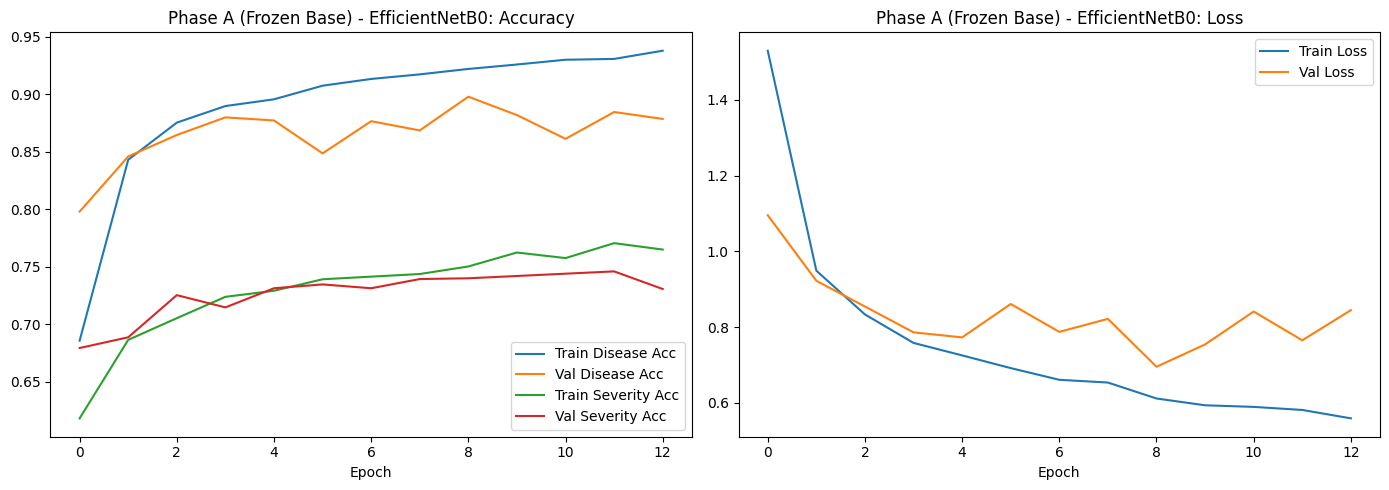

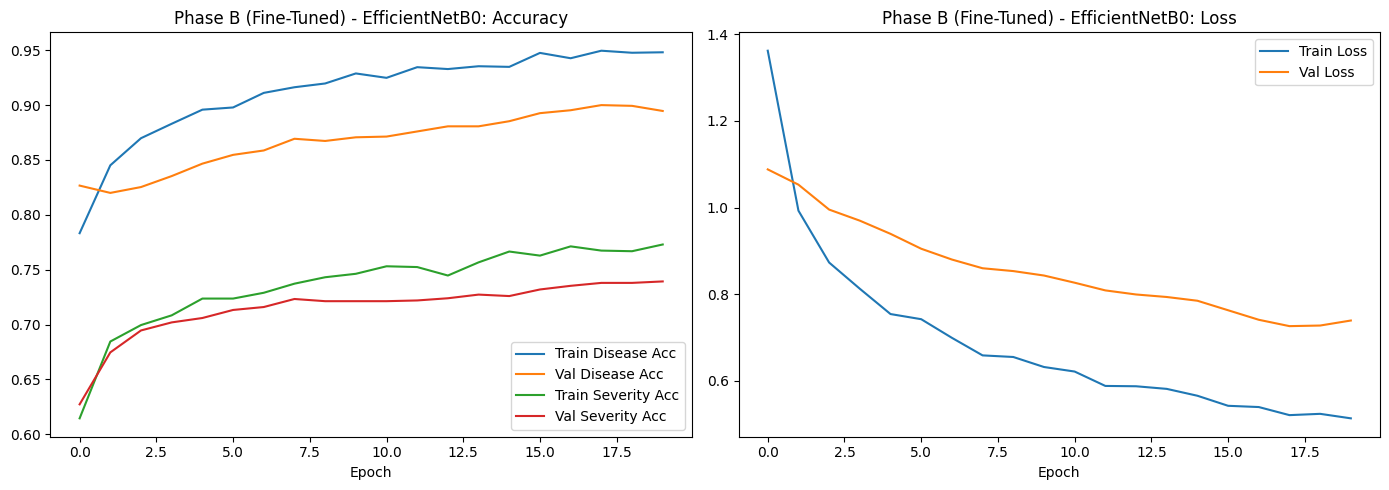

In [ ]:
def plot_history(history, phase_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['disease_output_accuracy'], label='Train Disease Acc')
    axes[0].plot(history.history['val_disease_output_accuracy'], label='Val Disease Acc')
    axes[0].plot(history.history['severity_output_accuracy'], label='Train Severity Acc')
    axes[0].plot(history.history['val_severity_output_accuracy'], label='Val Severity Acc')
    axes[0].set_title(f'{phase_name}: Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{phase_name}: Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_a, "Phase A (Frozen Base) - EfficientNetB0")
plot_history(history_b, "Phase B (Fine-Tuned) - EfficientNetB0")

## Step 12: Final Evaluation on Test Set

Same test set (identical split, same `random_state=42`) as the MobileNetV2 run, so these numbers are
directly comparable side-by-side in your results table.

In [ ]:
y_disease_true, y_severity_true = [], []
y_disease_pred, y_severity_pred = [], []

t0 = time.time()
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    disease_preds = np.argmax(preds[0], axis=1)
    severity_preds = np.argmax(preds[1], axis=1)

    y_disease_true.extend(labels['disease_output'].numpy())
    y_severity_true.extend(labels['severity_output'].numpy())
    y_disease_pred.extend(disease_preds)
    y_severity_pred.extend(severity_preds)
inference_time = time.time() - t0
print(f"Inference time on test set ({len(y_disease_true)} images): {inference_time:.2f} sec "
      f"({(inference_time/len(y_disease_true))*1000:.2f} ms/image)")

print("\n=== DISEASE CLASSIFICATION REPORT (EfficientNetB0) ===")
print(classification_report(y_disease_true, y_disease_pred, target_names=disease_encoder.classes_))

print("=== SEVERITY CLASSIFICATION REPORT (EfficientNetB0) ===")
print(classification_report(y_severity_true, y_severity_pred, target_names=SEVERITY_NAMES))

Inference time on test set (1500 images): 21.34 sec (14.23 ms/image)

=== DISEASE CLASSIFICATION REPORT (EfficientNetB0) ===
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.99      0.79      0.88       150
                        Tomato___Early_blight       0.82      0.88      0.85       150
                         Tomato___Late_blight       0.89      0.95      0.92       150
                           Tomato___Leaf_Mold       0.88      0.99      0.93       150
                  Tomato___Septoria_leaf_spot       0.84      0.91      0.87       150
Tomato___Spider_mites Two-spotted_spider_mite       0.94      0.72      0.82       150
                         Tomato___Target_Spot       0.92      0.81      0.86       150
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.97      0.95      0.96       150
                 Tomato___Tomato_mosaic_virus       0.81      1.00      0.89       150
    

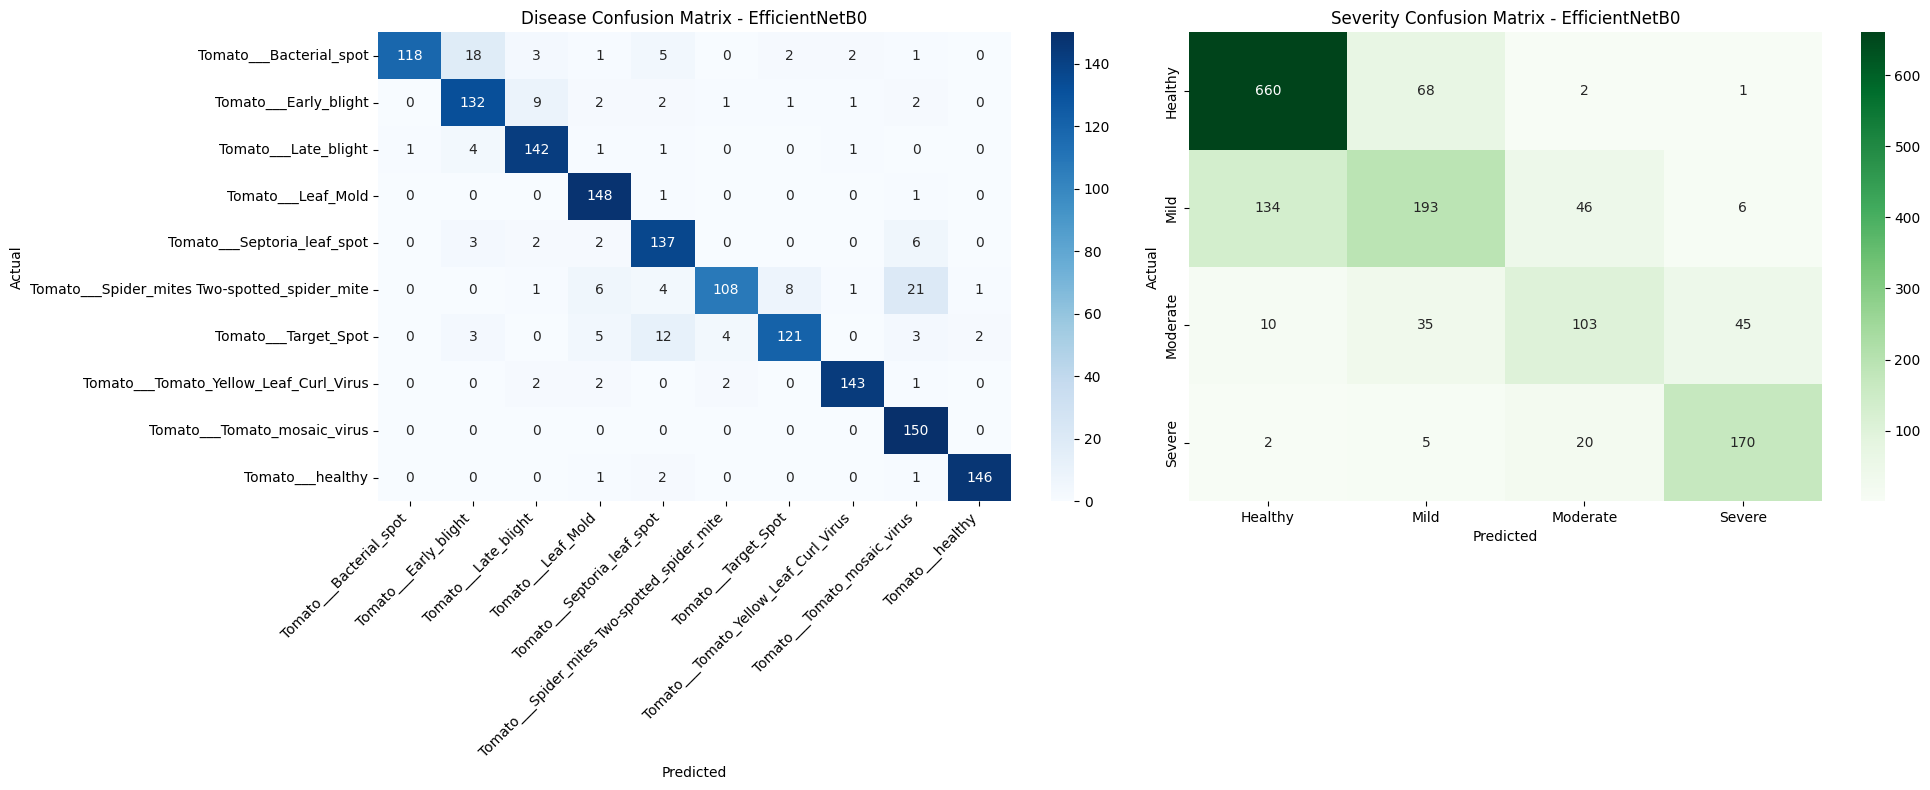

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_disease = confusion_matrix(y_disease_true, y_disease_pred)
sns.heatmap(cm_disease, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_encoder.classes_, yticklabels=disease_encoder.classes_, ax=axes[0])
axes[0].set_title('Disease Confusion Matrix - EfficientNetB0')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

cm_severity = confusion_matrix(y_severity_true, y_severity_pred)
sns.heatmap(cm_severity, annot=True, fmt='d', cmap='Greens',
            xticklabels=SEVERITY_NAMES, yticklabels=SEVERITY_NAMES, ax=axes[1])
axes[1].set_title('Severity Confusion Matrix - EfficientNetB0')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 13: Grad-CAM — Explainability

**Only change from the MobileNetV2 version:** `last_conv_layer_name` is now `"top_conv"` — that's
EfficientNetB0's final convolutional layer (MobileNetV2's was `"Conv_1"`). The preprocessing call inside
`display_gradcam` also uses `efficientnet.preprocess_input` to match Step 6.

Actual disease: Tomato___Late_blight


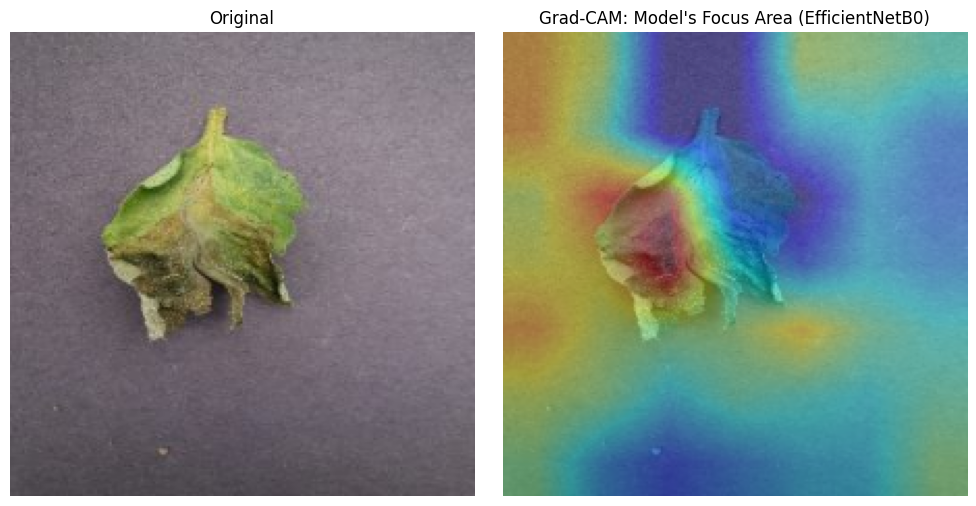

In [ ]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="top_conv", pred_index=None):
    conv_layer = base_model.get_layer(last_conv_layer_name)
    grad_model = keras.Model(inputs=base_model.input, outputs=[conv_layer.output, base_model.output])

    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(img_array)

        x = model.get_layer('global_average_pooling2d')(base_output)
        x = model.get_layer('dropout')(x)
        shared = model.get_layer('shared_dense')(x)
        shared = model.get_layer('dropout_1')(shared)
        disease_branch = model.get_layer('dense')(shared)
        disease_preds = model.get_layer('disease_output')(disease_branch)

        if pred_index is None:
            pred_index = tf.argmax(disease_preds[0])
        class_channel = disease_preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, model, base_model, last_conv_layer_name="top_conv", alpha=0.4):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_array = keras.applications.efficientnet.preprocess_input(np.expand_dims(img.numpy(), axis=0))

    heatmap = make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = img.numpy().astype('uint8')
    superimposed = cv2.addWeighted(original, 1 - alpha, heatmap_colored, alpha, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Grad-CAM: Model's Focus Area (EfficientNetB0)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

sample_path = test_df.iloc[0]['filepath']
print("Actual disease:", test_df.iloc[0]['disease'])
display_gradcam(sample_path, model, base_model)

**Note:** if `"top_conv"` errors on your TF version, run `base_model.summary()` and look for the last
layer with `Conv` in its name (usually the layer right before the final `BatchNormalization`/`Activation`
pair at the end of the backbone) and use that name instead.

## Step 14: Save & Export for Deployment

Same two export formats as before, with `_effnet` suffixes so they don't overwrite your MobileNetV2 files.

In [ ]:
model.save('/content/tomato_disease_severity_model_effnet.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('/content/tomato_model_effnet.tflite', 'wb') as f:
    f.write(tflite_model)

print("Saved: tomato_disease_severity_model_effnet.keras and tomato_model_effnet.tflite")

import os as _os
tflite_size_kb = _os.path.getsize('/content/tomato_model_effnet.tflite') / 1024
print(f"TFLite model size: {tflite_size_kb:.1f} KB")

label_map = {
    "disease_classes": list(disease_encoder.classes_),
    "severity_classes": SEVERITY_NAMES
}
with open('/content/label_map_effnet.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print("Saved label_map_effnet.json")

Saved artifact at '/tmp/tmpw4wnwkrg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  List[TensorSpec(shape=(None, 10), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)]
Captures:
  133453090816464: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133453090817808: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133453095584400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133453095586320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133453095585936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133453541326288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133453095587280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133453095586896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133453095589008: TensorSpec(shape=(), dtype=tf.resource, name=None)

## Step 15: (Optional) Download Your Trained Files

In [ ]:
from google.colab import files
files.download('/content/tomato_disease_severity_model_effnet.keras')
files.download('/content/tomato_model_effnet.tflite')
files.download('/content/label_map_effnet.json')

## Step 16: Build the Comparison Table

This is the piece your MobileNetV2 notebook doesn't have — a summary block pulling the numbers your paper
actually needs into one table: parameter count, model size, training time, inference speed, and accuracy
for both tasks. **Fill in the MobileNetV2 numbers manually from your other notebook's output** (or better:
copy this cell into that notebook too, so both produce a row in the same format).

In [ ]:
comparison_row_efficientnet = {
    "Backbone": "EfficientNetB0",
    "Total Params": f"{model.count_params():,}",
    "TFLite Size (KB)": round(tflite_size_kb, 1),
    "Phase A Time (s)": round(phaseA_time, 1),
    "Phase B Time (s)": round(phaseB_time, 1),
    "Inference (ms/img)": round((inference_time/len(y_disease_true))*1000, 2),
    "Disease Test Accuracy": round(
        classification_report(y_disease_true, y_disease_pred, target_names=disease_encoder.classes_, output_dict=True)['accuracy'], 4),
    "Severity Test Accuracy": round(
        classification_report(y_severity_true, y_severity_pred, target_names=SEVERITY_NAMES, output_dict=True)['accuracy'], 4),
}

comparison_df = pd.DataFrame([comparison_row_efficientnet])
print(comparison_df.to_string(index=False))
comparison_df.to_csv('/content/comparison_efficientnet.csv', index=False)
print("\nSaved comparison_efficientnet.csv — merge this with the MobileNetV2 row for your paper's table.")

      Backbone Total Params  TFLite Size (KB)  Phase A Time (s)  Phase B Time (s)  Inference (ms/img)  Disease Test Accuracy  Severity Test Accuracy
EfficientNetB0    4,428,401            4818.7             295.3             414.2               14.23                 0.8967                  0.7507

Saved comparison_efficientnet.csv — merge this with the MobileNetV2 row for your paper's table.
